In [ ]:
import  cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from collections import  deque
import time
import os
import pyautogui
import threading

In [2]:
labels = ['SwipeR','SwipeL','none','clap']
seqL = 150
numseq = 150

In [3]:
def landmarkgetter(sequence):
        data = np.zeros(126, dtype=np.float32)
        if sequence.hand_landmarks:
            for i , hand in enumerate(sequence.hand_landmarks[:2]):
                ofst = i * 63
                for j, lm in enumerate(hand):
                    data[ofst+j * 3+0]=lm.x
                    data[ofst+j * 3+1]=lm.y
                    data[ofst+j * 3+2]=lm.z
        return data

In [ ]:
def collectDataset():
    modelpath = 'hand_landmarker.task'
    if not os.path.exists(modelpath):
        import urllib.request
        urllib.request.urlretrieve(
            'https://storage.googleapis.com/mediapipe-assets/hand_landmarker.task',
            modelpath
        )

    labels = ['SwipeR','SwipeL','none','clap']
    seqL = 150
    numseq = 150
    base_options = python.BaseOptions(model_asset_path=modelpath)
    options = vision.HandLandmarkerOptions(base_options=base_options,
                                       num_hands=2)
    detector = vision.HandLandmarker.create_from_options(options)
    os.makedirs('dataset', exist_ok = True)
    for label in labels:
        os.makedirs(os.path.join('dataset',label), exist_ok = True)
  
   
    cap = cv2.VideoCapture(0)
    for label in labels:
        print(f'Collecting for {label}')
        time.sleep(5)
        seq = deque(maxlen = seqL)
        for _ in range(numseq):
            while True:
                ret, frame = cap.read()
                if not ret:
                    continue
                frame = cv2.flip(frame,1)
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
                result = detector.detect(mp_image)
                if result.hand_landmarks:
                    for hand_landmarks in result.hand_landmarks:
                        for lm in hand_landmarks:
                            cx, cy = int(lm.x * frame.shape[1]), int(lm.y * frame.shape[0])
                            cv2.circle(frame, (cx, cy), 4, (0, 255, 0), -1)

                data = landmarkgetter(result)
                seq.append(data)
                cv2.putText(frame, f'Recording: {label}', (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 200, 255), 2)
                cv2.putText(frame, f'Frames: {len(seq)}/{seqL}', (10, 80),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200, 200, 200), 1)

                cv2.imshow('frame', frame)
                cv2.waitKey(1)
                if len(seq) == seqL:
                    np.save(os.path.join('dataset',label,f'{time.time()}.npy'), np.array(seq))
                    break
                
    cap.release()
    cv2.destroyAllWindows()
if __name__ == '__main__':

    collectDataset()
    


I0000 00:00:1778626769.282229  230328 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778626769.285489  230341 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.6-arch1.1), renderer: AMD Radeon Vega 10 Graphics (radeonsi, raven, ACO, DRM 3.64, 7.0.3-arch1-2)
W0000 00:00:1778626769.298188  230330 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778626769.308491  230336 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [4]:
class lstm(nn.Module):
    
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, 64, batch_first=True)
        self.drop1 = nn.Dropout(0.3)
        self.lstm2 = nn.LSTM(64, 32, batch_first=True)
        self.drop2 = nn.Dropout(0.3)
        self.fc1 = nn.Linear(32, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.drop1(x)
        x, _ = self.lstm2(x)
        x = self.drop2(x)
        x = x[:, -1, :]
        x = self.relu(self.fc1(x))
        return self.fc2(x)


Training on: cpu
Epoch   1/200  train loss 0.0022  acc 44.0%  |  val loss 1.2648  acc 67.2%
model(val acc 67.2%)
Epoch   2/200  train loss 0.0006  acc 75.8%  |  val loss 0.6959  acc 84.4%
model(val acc 84.4%)
Epoch   3/200  train loss 0.0024  acc 90.7%  |  val loss 0.5982  acc 89.4%
model(val acc 89.4%)
Epoch   4/200  train loss 0.0004  acc 93.6%  |  val loss 0.1812  acc 96.7%
model(val acc 96.7%)
Epoch   5/200  train loss 0.0000  acc 97.5%  |  val loss 0.1460  acc 96.7%
Epoch   6/200  train loss 0.0000  acc 97.4%  |  val loss 0.0498  acc 99.4%
model(val acc 99.4%)
Epoch   7/200  train loss 0.0021  acc 98.2%  |  val loss 0.1937  acc 95.6%
Epoch   8/200  train loss 0.0000  acc 98.6%  |  val loss 0.0615  acc 97.8%
Epoch   9/200  train loss 0.0000  acc 97.5%  |  val loss 0.0257  acc 98.9%
Epoch  10/200  train loss 0.0000  acc 99.4%  |  val loss 0.0517  acc 98.3%
Epoch  11/200  train loss 0.0000  acc 97.6%  |  val loss 0.0525  acc 98.3%
Epoch  12/200  train loss 0.0014  acc 99.3%  |  val l

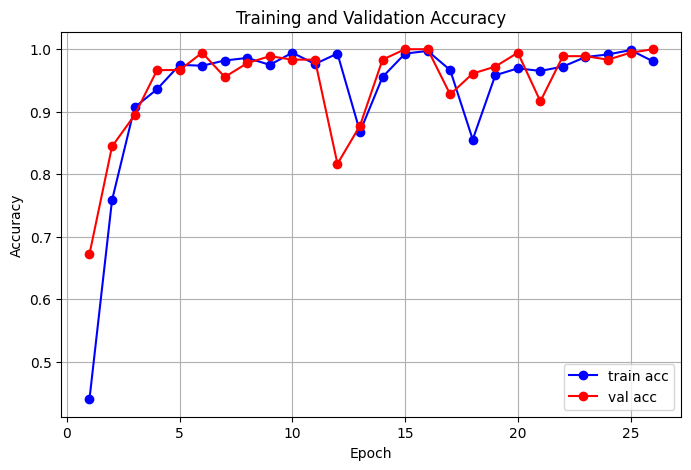


Best accuracy : 100.0%


In [ ]:



device = torch.device("cpu")
print(f"Training on: {device}")

X, Y, labels_list = [], [], []
for label in labels:
    label_dir = os.path.join('dataset', label)
    for file in os.listdir(label_dir):
        data = np.load(os.path.join(label_dir, file))
        if data.shape != (150, 126):
            print(f"Skipping {file} — shape {data.shape}")
            continue
        X.append(data)
        Y.append(labels.index(label))
        if label not in labels_list:
            labels_list.append(label)
X = np.array(X)
Y = np.array(Y)
model = lstm(input_size=X.shape[2], num_classes=len(labels_list)).to(device)
criterion = nn.CrossEntropyLoss()
LR = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

bstacc = 0.0
pat = 0

epochs = 200
patience = 20
thistory = []
vhistory = []

for epoch in range(1, epochs + 1):
    model.train()
    class Gestures():
        def __init__(self, x, y):
            self.x = torch.from_numpy(x).float()
            self.y = torch.from_numpy(y).long()
        def __len__(self):
            return len(self.y)
        def __getitem__(self, idx):
            return self.x[idx], self.y[idx]

    dataset = Gestures(X, Y)
    vals = max(1, int(0.2 * len(dataset)))
    trains = len(dataset) - vals
    train, val = torch.utils.data.random_split(dataset, [trains, vals])
    trainloader = torch.utils.data.DataLoader(train, batch_size=16, shuffle=True)
    valloader = torch.utils.data.DataLoader(val, batch_size=16, shuffle=False)

    loss, crct, ttl = 0.0, 0, 0
    for xb, yb in trainloader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        loss += loss.item() * len(yb)
        crct += (out.argmax(1) == yb).sum().item()
        ttl += len(yb)

    model.eval()
    vloss, vcrct, vttl = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in valloader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            vloss += loss.item() * len(yb)
            vcrct += (out.argmax(1) == yb).sum().item()
            vttl += len(yb)

    tacc = crct / ttl
    thistory.append(tacc)
    vacc = vcrct / vttl
    vhistory.append(vacc)
    print(f"Epoch {epoch:3d}/{epochs}  "
          f"train loss {loss/ttl:.4f}  acc {tacc*100:.1f}%  |  "
          f"val loss {vloss/vttl:.4f}  acc {vacc*100:.1f}%")
    

    if vacc > bstacc:
        bstacc = vacc
        MODEL_DIR = 'models'
        os.makedirs(MODEL_DIR, exist_ok=True)
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "gesture_lstm.pt"))
        print(f"model(val acc {vacc*100:.1f}%)")
    else:
        pat += 1
        if pat >= patience:
            print(f"early epoch {epoch}.")
            break

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(thistory) + 1), thistory, 'bo-', label='train acc')
plt.plot(range(1, len(vhistory) + 1), vhistory, 'ro-', label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

np.save(os.path.join(MODEL_DIR, "labels.npy"), np.array(labels_list))
print(f"\nBest accuracy : {bstacc*100:.1f}%")

        


In [ ]:
def realtimegestureRec():
    MODEL_DIR = 'models'
    modelp = os.path.join(MODEL_DIR, "gesture_lstm.pt")
    labelsp = os.path.join(MODEL_DIR, "labels.npy")
    sql = 15
    holdtime = 0.2
    waittine = 2
    threshs = {'clap': 0.5, 'SwipeL': 0.5, 'SwipeR': 0.5}
    
    labellist = list(np.load(labelsp, allow_pickle=True))
    nclass = len(labellist)
    device = torch.device("cpu")
    model = lstm(input_size=126, num_classes=nclass).to(device)
    model.load_state_dict(torch.load(modelp, map_location=device))
    model.eval()
    base = python.BaseOptions(model_asset_path='hand_landmarker.task')
    options = vision.HandLandmarkerOptions(base_options=base, num_hands=2)
    detector = vision.HandLandmarker.create_from_options(options)
    seq = deque(maxlen=sql)
    predlabel = ''
    predconf = 0.0
    predtime = 0
    last_triggered = {
    'clap': 0.0,
    'SwipeL': 0.0,
    'SwipeR': 0.0
    }
    cap = cv2.VideoCapture(0)
    while True:
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        result = detector.detect(mp_image)
        now = time.time()
        if result.hand_landmarks:
            for hand_landmarks in result.hand_landmarks:
                for lm in hand_landmarks:
                    cx, cy = int(lm.x * frame.shape[1]), int(lm.y * frame.shape[0])
                    cv2.circle(frame, (cx, cy), 4, (0, 255, 0), -1)
        data = landmarkgetter(result)
        seq.append(data)
        if len(seq) == sql:
            with torch.no_grad():
                input_data = torch.from_numpy(np.array(seq)).float().unsqueeze(0).to(device)
                out = model(input_data)
                probs = torch.softmax(out, dim=1).cpu().numpy()[0]
                pred = int(np.argmax(probs))
                conf = float(probs[pred])
                label = labellist[pred]
            if label in threshs and conf >= threshs[label]:
                if now - last_triggered[label] >= waittine:
                    last_triggered[label] = now
                    predlabel = label
                    predconf = conf
                    predtime = now
                    seq.clear()
                    if label == 'clap':
                        threading.Thread(
    target=lambda: os.system('ffplay -nodisp -autoexit clapping.mp3'),
    daemon=True
).start()
                    elif label == 'SwipeL':
                        pyautogui.press('left')
                        
                    elif label == 'SwipeR':
                        pyautogui.press('right')
                        
        if predlabel != '':
            cv2.putText(frame, f'{predlabel} {predconf*100:.1f}%', (10, 40),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 200, 255), 2)
            if time.time() - predtime > holdtime:
                predlabel = ''
        for i, (g, last) in enumerate(last_triggered.items()):
            remaining = max(0.0, waittine - (now - last))
            status = f"{g}: ready" if remaining == 0 else f"{g}: {remaining:.0f}s"
            cv2.putText(frame, status, (10, frame.shape[0] - 20 - i*22),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (180, 180, 180), 1)
        cv2.imshow('frame', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()
realtimegestureRec()

I0000 00:00:1778630361.118081  265087 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778630361.121603  265100 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.6-arch1.1), renderer: AMD Radeon Vega 10 Graphics (radeonsi, raven, ACO, DRM 3.64, 7.0.3-arch1-2)
W0000 00:00:1778630361.131652  265091 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778630361.143896  265094 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
ffplay version n8.1.1 Copyright (c) 2003-2026 the FFmpeg developers
  built with gcc 16.1.1 (GCC) 20260430
  configuration: --prefix=/usr --disable-debug --disable-static --disable-stripping --enable-amf --enable-avisynth --enable-cuda-llvm --enable-lto --enable-fontconfig --enable-frei0r --enable-gmp --enable-gnutls --enable-gpl

ffplay version n8.1.1 Copyright (c) 2003-2026 the FFmpeg developers
  built with gcc 16.1.1 (GCC) 20260430
  configuration: --prefix=/usr --disable-debug --disable-static --disable-stripping --enable-amf --enable-avisynth --enable-cuda-llvm --enable-lto --enable-fontconfig --enable-frei0r --enable-gmp --enable-gnutls --enable-gpl --enable-ladspa --enable-lcms2 --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libdav1d --enable-libdrm --enable-libdvdnav --enable-libdvdread --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgsm --enable-libharfbuzz --enable-libiec61883 --enable-libjack --enable-libjxl --enable-libmodplug --enable-libmp3lame --enable-libopencore_amrnb --enable-libopencore_amrwb --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libplacebo --enable-libpulse --enable-librav1e --enable-librsvg --enable-librubberband --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-l

ffplay version n8.1.1 Copyright (c) 2003-2026 the FFmpeg developers
  built with gcc 16.1.1 (GCC) 20260430
  configuration: --prefix=/usr --disable-debug --disable-static --disable-stripping --enable-amf --enable-avisynth --enable-cuda-llvm --enable-lto --enable-fontconfig --enable-frei0r --enable-gmp --enable-gnutls --enable-gpl --enable-ladspa --enable-lcms2 --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libdav1d --enable-libdrm --enable-libdvdnav --enable-libdvdread --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgsm --enable-libharfbuzz --enable-libiec61883 --enable-libjack --enable-libjxl --enable-libmodplug --enable-libmp3lame --enable-libopencore_amrnb --enable-libopencore_amrwb --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libplacebo --enable-libpulse --enable-librav1e --enable-librsvg --enable-librubberband --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-l